# 238 — over-factor and filter, and reliability-based electrode selection

Fit **more** components than any criterion supports, then keep only the ones that
survive a stability test — the strategy Norman-Haignere et al. (2019) used, with the
filter changed to target the failure this dataset actually has.

**They** fitted 20 components and restricted their analyses to 14: stable across 1000
random initialisations (median r > 0.9 against the next 99 best, Fig 1G) and not
driven by one subject (max normalised subject weight < 0.5, Fig 1F).

**The critical detail: the MODEL stayed at 20.** They did not refit at 14 and never
claimed 14 components explain the data. In NMF the components are fitted jointly, so
deleting some and keeping the rest leaves something that reconstructs nothing. The
filter restricts *interpretation*, not the model. This notebook keeps that discipline.

**The change:** their initialisation filter catches components that move between
random starts. The primary filter here is the **bootstrap** — resample the electrodes,
refit, ask whether the component comes back — because that is the failure this data
has. Initialisation and patient filters are reported alongside.

---

## ⚠️ CORRECTION 2026-08-21 — the earlier results from this notebook were wrong

Every bootstrap number this notebook produced before today was **biased down by a
factor of 1 − 1/e = 0.632**, and the headline that followed from them — *nothing
clears Hennig's 0.60 at any K* — was an artefact of that bug, not a finding.

A bootstrap of size *n* draws each row with probability 1 − (1 − 1/n)ⁿ → 0.632. The
rows it never draws cannot be recovered by the refit. The old code left them in the
original cluster while they were absent from the refit's, so they sat in the Jaccard
**denominator** and never in the numerator. The statistic was capped at 0.632 while
being compared against thresholds — 0.60 and 0.75 — defined on a scale where 1.0 means
perfect recovery.

Verified, not argued: feeding the old procedure an *exact* reproduction of the
partition returned **0.6322 ± 0.0084** over 200 resamples. It should return 1.0.

On the real K=7 cNMF run the bug cost **0.23–0.31 Jaccard per cluster** and turned
seven passes into none:

| cluster | n | old (buggy) | corrected |
|---|---|---|---|
| c0 | 139 | 0.472 | **0.709** |
| c1 | 169 | 0.569 | **0.865** |
| c2 | 186 | 0.425 | **0.652** |
| c3 | 132 | 0.516 | **0.799** |
| c4 | 191 | 0.526 | **0.828** |
| c5 | 297 | 0.560 | **0.874** |
| c6 | 152 | 0.562 | **0.851** |

The old "best J = 0.59" across every K was sitting just under the 0.632 ceiling, which
is what gave the bug away. **The old table of results has been deleted from this
notebook rather than corrected — every run needs redoing.**

## What else changed, so a number here can be trusted

A mean over 25 resamples compared to a fixed threshold was never enough to hang a
pass/fail on. Three additions:

1. **Confidence interval on every mean.** A cluster is judged by its interval, not by
   which side of the line its point estimate lands on. At sd = 0.15 and 25 resamples
   the 95% half-width is 0.052 — wide enough to straddle the threshold.
2. **A calibrated null.** Hennig's 0.60 is a rule of thumb, not a level derived for a
   given K, n and set of cluster sizes. Jaccard has a floor that moves with all three,
   so a fixed threshold is a *different test at every K* and "stability degrades as K
   rises" is partly arithmetic. The null here is structureless data with the same
   covariance, run through the identical procedure.
3. **A convergence check**, so it is visible whether 25 resamples was enough rather
   than assumed. This is the mistake FIG C.7 already made once at 3 repetitions.

Plus a **sweep** so a grid of runs is one cell rather than editing three constants and
re-running by hand, and a summary table **generated from the saved results** rather
than typed into this markdown, where it would drift the moment a new K was run.

In [23]:
import sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
sys.path.insert(0, "functions")
import lf_decompose as LD
import measure_cluster_stability as MS   # bootstrap_jaccard(), ci95(), null_bootstrap()

# ── what to run ───────────────────────────────────────────────────────────────
METHOD      = "cnmf"           # "cnmf" | "kmeans" | "hierarchical"
FEATURE_SET = "concat_hg"      # "concat_hg" (gated) | "concat_hg_all" (ungated)
K_OVER      = 10               # ask for MORE than any criterion supports

N_BOOT   = 100      # bootstrap resamples
N_SEEDS  = 10      # random restarts
N_NULL   = 2       # surrogate datasets for the null level (0 to skip, it is the slow part)

BOOT_MIN = 0.60    # Hennig 2007: < 0.60 is not a real cluster
INIT_MIN = 0.75
PAT_MAX  = 0.50    # Norman-Haignere Fig 1F

# Its own folder, kept clear of every other "stability" number in this project.
# comparison/ holds the pre-correction runs (OLD below points at them, read-only);
# the Monti consensus scores live inside each run dir as per_cluster_stability.csv.
# Neither is on the same scale as what this notebook computes - see the README.
OUT = Path("outputs/clustering/overfactor_stability"); OUT.mkdir(parents=True, exist_ok=True)
OLD = Path("outputs/clustering/comparison")     # pre-correction results, never read
ALL_CSV = OUT / "boot_ALL.csv"                  # every component of every run, long form
MEASURE = "hennig_bootstrap_jaccard_inbag"      # stamped on every row, so a value
                                                # from here cannot be read as a Monti one
TAG = f"{METHOD}_{FEATURE_SET}_K{K_OVER}"

RUN, SPACE = MS.resolve(METHOD, FEATURE_SET)
print(f"{METHOD} / {FEATURE_SET}  ->  {RUN.name}")
print(f"fits in {SPACE} space, over-factoring to K = {K_OVER}")
print(f"bootstrap {N_BOOT} x, seeds {N_SEEDS}, null datasets {N_NULL}")

cnmf / concat_hg  ->  20260818_112939
fits in unit-norm space, over-factoring to K = 10
bootstrap 100 x, seeds 10, null datasets 2


## 1. Fit the over-factored model

**Each method is fitted in the space it actually uses.** `X_train.npy` is raw dB;
convex NMF unit-norms each electrode before fitting, k-means and Ward do not. Scoring
all three in dB is the error that made the first version of FIG C.7 wrong, and every
measure below — silhouette included — is space-dependent.

The last line is a **drift check**. This notebook refits rather than reading the run's
saved labels, so at matched K the two should agree almost perfectly. If they do not,
the components analysed here are not the ones the visualizer and FIG C.9 display, and
nothing below is comparable to anything on the site.

In [24]:
X  = np.load(RUN / "X_train.npy").astype(float)
A  = MS.unit(X) if SPACE == "unit-norm" else X
lab_df = pd.read_csv(RUN / "labels.csv")
patients = lab_df["patient_id"].astype(str).to_numpy()
n = len(A)

# the gate flag rides along in labels.csv; on a gated run every row is True
gate = None
if "n_high_activity" in lab_df.columns:
    g = pd.to_numeric(lab_df["n_high_activity"], errors="coerce").fillna(0).to_numpy() > 0
    if (~g).any():
        gate = g

Gn = None
if METHOD == "cnmf":
    G = LD.convex_nmf(A, K_OVER, n_iter=300, random_state=0)[1]
    Gn = G / np.maximum(G.sum(1, keepdims=True), 1e-12)
    base = Gn.argmax(1)
else:
    base = MS.fit_any(A, K_OVER, 0, METHOD)

ids = sorted(set(int(v) for v in base))
members = {j: np.where(base == j)[0] for j in ids}
print(f"{n} electrodes x {X.shape[1]} features")
print("cluster sizes:", [len(members[j]) for j in ids])
if gate is not None:
    print(f"ungated set: {100*(~gate).mean():.1f}% of electrodes were added by lifting the gate")

# ---- drift check against the run's own saved labels, at matched K only
from sklearn.metrics import adjusted_rand_score
saved = None
for cand in ("cluster_labels_by_k.csv", "labels.csv"):
    p = RUN / cand
    if not p.exists():
        continue
    df = pd.read_csv(p)
    col = (f"k_{K_OVER}" if f"k_{K_OVER}" in df.columns else
           next((c for c in df.columns
                 if c.startswith("cluster_") and not c.endswith("_ranked")), None))
    if col is not None:
        saved = pd.to_numeric(df[col], errors="coerce").to_numpy()
        break
if saved is None or len(saved) != n:
    print("\nno saved labels to compare against - drift check skipped")
elif len(set(saved[~np.isnan(saved)].astype(int))) != K_OVER:
    print(f"\nsaved labels are at K={len(set(saved.astype(int)))}, not {K_OVER} "
          "- drift check not applicable at this K")
else:
    ari = adjusted_rand_score(saved.astype(int), base)
    print(f"\ndrift check vs saved labels: ARI = {ari:.3f}"
          + ("  OK" if ari > 0.95 else "  <-- WARNING: this is not the published partition"))

1266 electrodes x 900 features
cluster sizes: [153, 144, 108, 115, 205, 84, 86, 112, 145, 114]

drift check vs saved labels: ARI = 1.000  OK


## 2. Filter A — bootstrap Jaccard (the one that bites)

Resample the electrodes **with replacement**, refit at the same K, and ask how much of
each original cluster is recovered by its best match. Hennig (2007): **> 0.75 stable,
0.60–0.75 a pattern, < 0.60 not a real cluster.**

**Scored on the rows the refit actually saw.** This is the line the correction turned
on. About 37% of rows are never drawn by any given bootstrap and cannot be recovered
by definition; leaving them in the original cluster caps the statistic at 0.632.
Restricting the original cluster to the in-bag rows is Hennig's own convention and
returns 1.0 on perfect recovery — checked.

**The refit uses a fixed seed.** Resampling variance is what is being measured here;
initialisation variance is filter B's job, and letting both move at once would
confound them.

What this does *not* say is that a surviving component is biologically meaningful —
only that it is not an accident of which electrodes were recorded.

In [25]:
t0 = time.time()
boot = MS.bootstrap_jaccard(A, members, K_OVER, METHOD, n_boot=N_BOOT)
boot_ci = {j: MS.ci95(boot[j]) for j in ids}
print(f"  {N_BOOT} resamples in {time.time()-t0:.0f}s")
print()
print("  %-4s %8s %16s %8s" % ("cl", "boot J", "95% CI", "sd"))
for j in ids:
    m, lo, hi = boot_ci[j]
    print("  c%-3d %8.3f   [%.3f, %.3f] %8.3f" % (j, m, lo, hi, boot[j].std(ddof=1)))

  100 resamples in 180s                 

  cl     boot J           95% CI       sd
  c0      0.818   [0.801, 0.834]    0.083
  c1      0.623   [0.595, 0.651]    0.139
  c2      0.491   [0.453, 0.529]    0.191
  c3      0.698   [0.652, 0.745]    0.233
  c4      0.709   [0.677, 0.740]    0.158
  c5      0.611   [0.575, 0.647]    0.182
  c6      0.743   [0.725, 0.761]    0.092
  c7      0.712   [0.687, 0.737]    0.126
  c8      0.856   [0.846, 0.867]    0.052
  c9      0.622   [0.586, 0.657]    0.179


### 2b. Was 25 resamples enough?

The left panel is the running mean: if a cluster's line is still moving at the right
edge, the number it reports is not settled. The right panel converts that into the
question you actually care about — how many resamples would it take to pin each mean
to ±0.05 — using the observed spread.

This exists because the same mistake has already been made once in this project: the
null in FIG C.7 was first run at 3 repetitions and moved by 0.8 z between seeds.

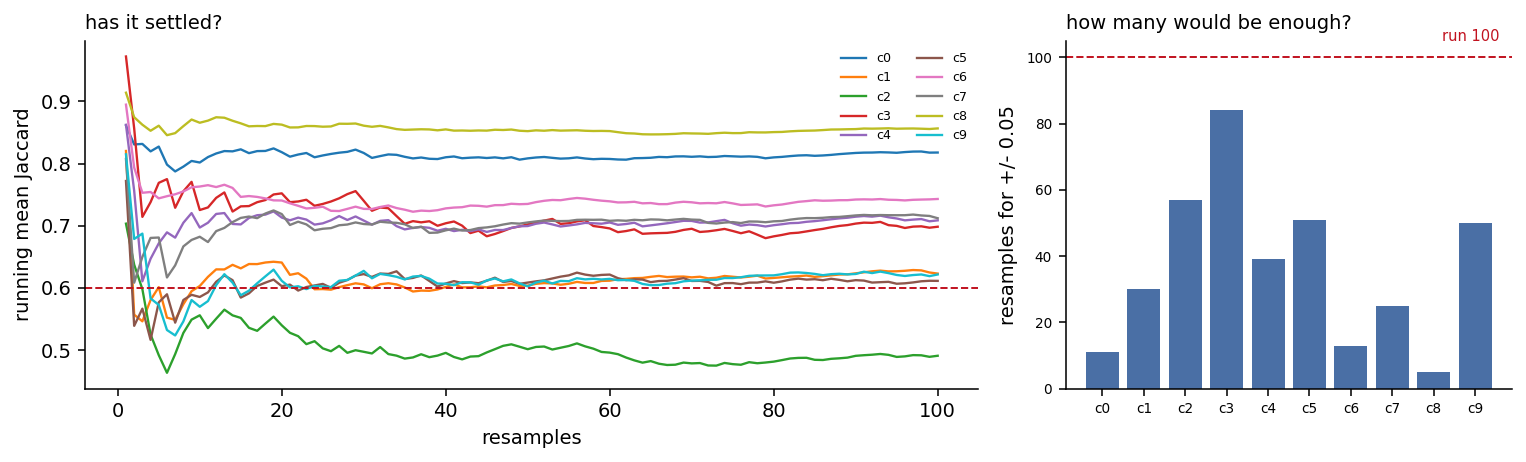

widest cluster needs ~84 resamples for a +/- 0.05 interval; 100 were run.


In [26]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(11, 3.4), dpi=140,
                               gridspec_kw={"width_ratios": [2, 1]})
for j in ids:
    run_mean = np.cumsum(boot[j]) / np.arange(1, N_BOOT + 1)
    axl.plot(np.arange(1, N_BOOT + 1), run_mean, lw=1.2, label=f"c{j}")
axl.axhline(BOOT_MIN, color="#c1121f", ls="--", lw=1)
axl.set_xlabel("resamples"); axl.set_ylabel("running mean Jaccard")
axl.set_title("has it settled?", fontsize=10, loc="left")
axl.legend(fontsize=6.5, ncol=2, frameon=False)

need = []
for j in ids:
    sd = boot[j].std(ddof=1)
    need.append(int(np.ceil((1.96 * sd / 0.05) ** 2)))
axr.bar([f"c{j}" for j in ids], need, color="#4a6fa5")
axr.axhline(N_BOOT, color="#c1121f", ls="--", lw=1)
axr.text(len(ids) - 0.4, N_BOOT * 1.05, f"run {N_BOOT}", color="#c1121f",
         fontsize=7.5, ha="right")
axr.set_ylabel("resamples for +/- 0.05")
axr.set_title("how many would be enough?", fontsize=10, loc="left")
axr.tick_params(labelsize=7)
for ax in (axl, axr):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

worst = max(need)
print(f"widest cluster needs ~{worst} resamples for a +/- 0.05 interval; "
      f"{N_BOOT} were run.")
if worst > N_BOOT:
    print("  -> at least one interval is wider than +/- 0.05. Raise N_BOOT before")
    print("     treating a near-threshold verdict from this run as settled.")

## 3. What does chance look like? — calibrating the threshold

**Hennig's 0.60 is a rule of thumb, not a level derived for this K, this n and these
cluster sizes.** Jaccard has a floor that moves with all three: a partition into a few
big clusters reproduces itself easily whatever the data, because a large cluster
overlaps its best match by a lot. A partition into many small ones does not.

Two consequences, both of which caught the earlier version of this notebook:

- **A fixed threshold is a different test at every K.** The old claim that stability
  "degrades as K rises" was partly arithmetic.
- **A big cluster passing is much weaker evidence than a small one passing.**

So run the identical procedure on data with **no cluster structure at all** — Gaussian
with this dataset's own covariance, so the features stay correlated and the time
courses stay smooth, but there is one blob. Whatever Jaccard that reaches is the floor.
White noise would be trivially beatable and would prove nothing.

The level to beat is the 95th percentile of the null's per-cluster values. This is the
slow cell: `N_NULL` × `N_BOOT/2` refits. Set `N_NULL = 0` to skip it, at the cost of
having no idea what the numbers above mean.

In [27]:
null_p95 = None
if N_NULL > 0:
    t0 = time.time()
    nv = MS.null_bootstrap(X, K_OVER, METHOD, SPACE, n_null=N_NULL,
                           n_boot=max(8, N_BOOT // 2))
    null_p95 = float(np.percentile(nv, 95))
    print(f"  {len(nv)} null clusters over {N_NULL} surrogates in {time.time()-t0:.0f}s")
    print(f"  null Jaccard: mean {nv.mean():.3f}, median {np.median(nv):.3f}, "
          f"95th pct {null_p95:.3f}, max {nv.max():.3f}")
    obs = np.array([boot_ci[j][0] for j in ids])
    print(f"  observed:     mean {obs.mean():.3f}, min {obs.min():.3f}, max {obs.max():.3f}")
    print()
    if null_p95 > BOOT_MIN:
        print(f"  NOTE: structureless data reaches {null_p95:.3f} here, ABOVE Hennig's "
              f"{BOOT_MIN}.")
        print("  At this K and these cluster sizes the 0.60 rule of thumb passes noise,")
        print("  so the null level is the binding threshold, not Hennig.")
    else:
        print(f"  Hennig's {BOOT_MIN} is the binding threshold here "
              f"(null reaches only {null_p95:.3f}).")
else:
    print("null calibration skipped (N_NULL = 0) - thresholds below are uncalibrated.")

  20 null clusters over 2 surrogates in 189s      
  null Jaccard: mean 0.289, median 0.293, 95th pct 0.351, max 0.362
  observed:     mean 0.688, min 0.491, max 0.856

  Hennig's 0.6 is the binding threshold here (null reaches only 0.351).


## 4. Filter B — initialisation stability

Refit from different random starts.

**Ward has no random initialisation** — it is deterministic, so this score is 1.0 by
construction and is not evidence of anything. The cell says so rather than letting it
look like a passed test.

In [28]:
DETERMINISTIC = METHOD == "hierarchical"
if DETERMINISTIC:
    init_J = {j: float("nan") for j in ids}
    print("Ward is deterministic - no random initialisation, so this filter does not apply.")
else:
    init = {j: [] for j in ids}
    for s in range(1, N_SEEDS + 1):
        ls = MS.fit_any(A, K_OVER, s, METHOD)
        for j in ids:
            init[j].append(MS.best_jaccard(members[j], ls,
                                           sorted(set(int(v) for v in ls))))
    init_J = {j: float(np.mean(v)) for j, v in init.items()}
    for j in ids:
        print(f"  c{j:<3} initialisation J {init_J[j]:.3f}")

  c0   initialisation J 0.942
  c1   initialisation J 0.804
  c2   initialisation J 0.712
  c3   initialisation J 0.887
  c4   initialisation J 0.862
  c5   initialisation J 0.839
  c6   initialisation J 0.879
  c7   initialisation J 0.851
  c8   initialisation J 0.933
  c9   initialisation J 0.750


## 5. Filter C — patient specificity

Norman-Haignere Fig 1F: drop a component if one subject holds more than half its
weight. Five of their twenty died this way.

**The quantity differs by method.** Convex NMF has loadings, so this is the share of
component *weight*, matching the paper. A hard partition has no weights, so it is the
share of *members* instead — a related but not identical quantity, and the 0.5
threshold carries over only loosely.

It also barely bites at this cohort size: they had **13 subjects**, this has **27**, so
a > 0.5 single-patient share is roughly twice as hard to reach.

In [29]:
shares = MS.patient_share(base, patients, Gn=Gn)
for j in ids:
    mx, who = shares[j]
    flag = "  <-- one patient dominates" if mx > PAT_MAX else ""
    print(f"  c{j:<3} largest patient share {mx:.3f} ({who}){flag}")

  c0   largest patient share 0.276 (EL033)
  c1   largest patient share 0.215 (PAT_6854)
  c2   largest patient share 0.173 (EL046)
  c3   largest patient share 0.249 (EL045)
  c4   largest patient share 0.389 (PAT_6953)
  c5   largest patient share 0.267 (PAT_3975)
  c6   largest patient share 0.232 (PAT_3780)
  c7   largest patient share 0.126 (PAT_6953)
  c8   largest patient share 0.171 (EL042)
  c9   largest patient share 0.166 (PAT_3455)


## 6. What survives — and what that licenses

**The model stays at K = K_OVER.** Nothing is deleted, nothing is refitted. The table
says which components are worth *naming*; the reconstruction and every loading still
come from the full model.

**The bootstrap verdict is taken from the CI lower bound**, not the point estimate. A
cluster whose interval straddles the threshold has not cleared it — it has failed to
resolve, which is a different thing from failing, and the `boot_lo`/`boot_hi` columns
say which.

If you later write "we found N components", that is wrong. The honest sentence is:
*a K=… decomposition was fitted; N of its components met the stability criteria and
only those are interpreted.*

In [30]:
rows = []
for j in ids:
    m, lo, hi = boot_ci[j]
    ok_b = lo >= BOOT_MIN                                   # lower bound, not the mean
    ok_n = True if null_p95 is None else (lo > null_p95)
    ok_i = True if DETERMINISTIC else (init_J[j] >= INIT_MIN)
    ok_p = shares[j][0] <= PAT_MAX
    r = dict(method=METHOD, feature_set=FEATURE_SET, K=K_OVER, component=j,
             n=len(members[j]),
             boot_J=round(m, 3), boot_lo=round(lo, 3), boot_hi=round(hi, 3),
             boot_sd=round(float(boot[j].std(ddof=1)), 3),
             pass_bootstrap=ok_b,
             null_p95=None if null_p95 is None else round(null_p95, 3),
             above_null=ok_n,
             init_J=None if DETERMINISTIC else round(init_J[j], 3), pass_init=ok_i,
             patient_max=round(shares[j][0], 3), pass_patient=ok_p,
             interpret=bool(ok_b and ok_n and ok_i and ok_p),
             n_boot=N_BOOT, measure=MEASURE, scoring="in-bag")
    if gate is not None:
        r["pct_added"] = round(float(100 * (~gate[base == j]).mean()), 1)
    rows.append(r)
tab = pd.DataFrame(rows).set_index("component")
display(tab.drop(columns=["method", "feature_set", "K", "measure", "scoring"]))

keep = tab.index[tab["interpret"]].tolist()
print(f"\n{METHOD} / {FEATURE_SET}  ({SPACE} space)")
print(f"MODEL: K={K_OVER}, unchanged.")
print(f"INTERPRET: {len(keep)} of {K_OVER} -> {keep}")
print(f"  failed bootstrap (CI lo < {BOOT_MIN}) : {tab.index[~tab['pass_bootstrap']].tolist()}")
if null_p95 is not None:
    print(f"  at or below the null ({null_p95:.3f})    : {tab.index[~tab['above_null']].tolist()}")
if not DETERMINISTIC:
    print(f"  failed init                        : {tab.index[~tab['pass_init']].tolist()}")
print(f"  failed patient                     : {tab.index[~tab['pass_patient']].tolist()}")

straddle = tab.index[(tab["boot_lo"] < BOOT_MIN) & (tab["boot_hi"] >= BOOT_MIN)].tolist()
if straddle:
    print(f"\n  UNRESOLVED (interval straddles {BOOT_MIN}): {straddle}")
    print("  These have not failed - they are not measured precisely enough to say.")
    print("  Raise N_BOOT if the verdict on them matters.")

tab.to_csv(OUT / f"boot_{TAG}.csv")

# append to the long-format store, replacing any previous rows for this exact run
allrows = tab.reset_index()
if ALL_CSV.exists():
    prev = pd.read_csv(ALL_CSV)
    prev = prev[~((prev["method"] == METHOD) & (prev["feature_set"] == FEATURE_SET)
                  & (prev["K"] == K_OVER))]
    allrows = pd.concat([prev, allrows], ignore_index=True)
allrows.to_csv(ALL_CSV, index=False)
print(f"\n-> {OUT / f'boot_{TAG}.csv'}  and appended to {ALL_CSV.name}")

,n,boot_J,boot_lo,boot_hi,boot_sd,pass_bootstrap,null_p95,above_null,init_J,pass_init,patient_max,pass_patient,interpret,n_boot
component,,,,,,,,,,,,,,
0,153,0.818,0.801,0.834,0.083,True,0.351,True,0.942,True,0.276,True,True,100
1,144,0.623,0.595,0.651,0.139,False,0.351,True,0.804,True,0.215,True,False,100
2,108,0.491,0.453,0.529,0.191,False,0.351,True,0.712,False,0.173,True,False,100
3,115,0.698,0.652,0.745,0.233,True,0.351,True,0.887,True,0.249,True,True,100
4,205,0.709,0.677,0.740,0.158,True,0.351,True,0.862,True,0.389,True,True,100
5,84,0.611,0.575,0.647,0.182,False,0.351,True,0.839,True,0.267,True,False,100
6,86,0.743,0.725,0.761,0.092,True,0.351,True,0.879,True,0.232,True,True,100
7,112,0.712,0.687,0.737,0.126,True,0.351,True,0.851,True,0.126,True,True,100
8,145,0.856,0.846,0.867,0.052,True,0.351,True,0.933,True,0.171,True,True,100



cnmf / concat_hg  (unit-norm space)
MODEL: K=10, unchanged.
INTERPRET: 6 of 10 -> [0, 3, 4, 6, 7, 8]
  failed bootstrap (CI lo < 0.6) : [1, 2, 5, 9]
  at or below the null (0.351)    : []
  failed init                        : [2]
  failed patient                     : []

  UNRESOLVED (interval straddles 0.6): [1, 5, 9]
  These have not failed - they are not measured precisely enough to say.
  Raise N_BOOT if the verdict on them matters.

-> outputs\clustering\overfactor_stability\boot_cnmf_concat_hg_K10.csv  and appended to boot_ALL.csv


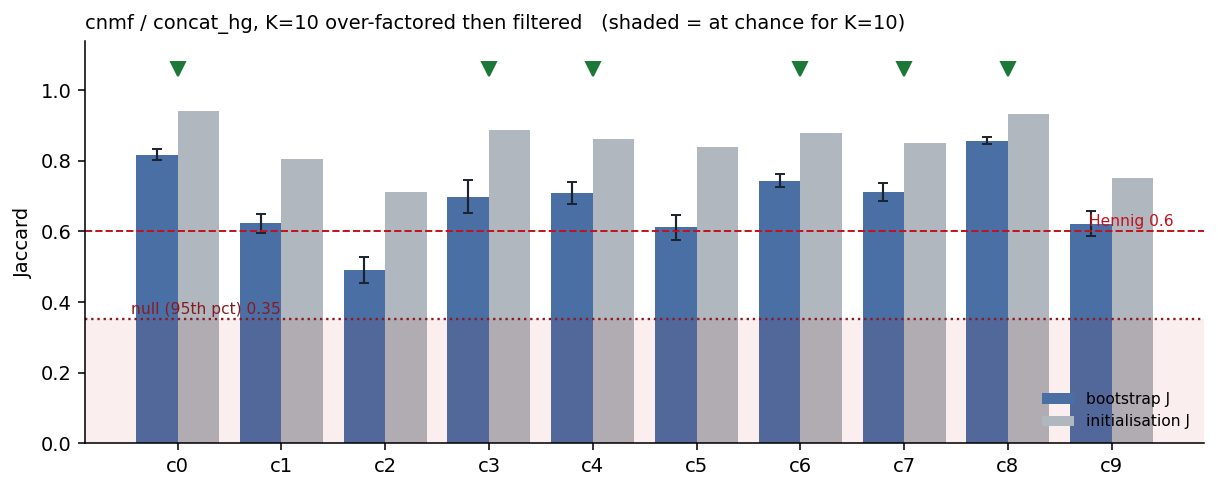

In [31]:
fig, ax = plt.subplots(figsize=(8.8, 3.6), dpi=140)
x = np.arange(len(ids))
mu = np.array([boot_ci[j][0] for j in ids])
lo = np.array([boot_ci[j][1] for j in ids])
hi = np.array([boot_ci[j][2] for j in ids])
ax.bar(x - 0.2, mu, width=0.4, color="#4a6fa5", label="bootstrap J")
ax.errorbar(x - 0.2, mu, yerr=[mu - lo, hi - mu], fmt="none", ecolor="#1b232c",
            lw=1.1, capsize=2.5)
if not DETERMINISTIC:
    ax.bar(x + 0.2, [init_J[j] for j in ids], width=0.4, color="#b0b7be",
           label="initialisation J")
ax.axhline(BOOT_MIN, color="#c1121f", ls="--", lw=1)
ax.text(len(ids) - 0.4, BOOT_MIN + 0.015, f"Hennig {BOOT_MIN:g}", color="#c1121f",
        fontsize=8, ha="right")
if null_p95 is not None:
    ax.axhspan(0, null_p95, color="#c1121f", alpha=0.07, lw=0)
    ax.axhline(null_p95, color="#8a1a20", ls=":", lw=1.2)
    ax.text(-0.45, null_p95 + 0.015, f"null (95th pct) {null_p95:.2f}",
            color="#8a1a20", fontsize=8, ha="left")
if gate is not None:
    for i, j in enumerate(ids):
        ax.text(i - 0.2, hi[i] + 0.025, f"{tab.loc[j,'pct_added']:.0f}%",
                ha="center", fontsize=6.5, color="#5f6a72")
for i, j in enumerate(ids):
    if tab.loc[j, "interpret"]:
        ax.plot(i, 1.06, marker="v", color="#1b7837", ms=7)
ax.set_xticks(x); ax.set_xticklabels([f"c{j}" for j in ids])
ax.set_ylim(0, 1.14); ax.set_ylabel("Jaccard")
ax.set_title(f"{METHOD} / {FEATURE_SET}, K={K_OVER} over-factored then filtered"
             + (f"   (shaded = at chance for K={K_OVER})" if null_p95 is not None else "")
             + ("   (% = share added by ungating)" if gate is not None else ""),
             fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / f"boot_{TAG}.png", dpi=140, bbox_inches="tight",
            facecolor="white")
plt.show()

## 7. Sweep — run the grid without editing constants

Everything above is one combination, laid out step by step so each filter can be read.
Once that is understood there is no reason to re-run it by hand: `sweep()` does the
same work for a list of combinations, **skips anything already saved**, and appends to
the same long-format store.

A cached run is only reused if it came from the corrected bootstrap **and** used at
least as many resamples as you are now asking for, so a quick exploratory pass at
`n_boot=5` cannot silently stand in for a real one.

The per-run diagnostics — the convergence panel, the null printout — are not drawn
here. If a combination lands somewhere interesting, set the constants at the top to it
and re-run sections 1–6 to see them.

In [32]:
def run_one(method, feature_set, k, n_boot=N_BOOT, n_seeds=N_SEEDS, n_null=N_NULL,
            force=False):
    """One combination, same procedure as sections 1-6, no plots. Returns a frame."""
    tag = f"{method}_{feature_set}_K{k}"
    csv = OUT / f"boot_{tag}.csv"
    if csv.exists() and not force:
        d = pd.read_csv(csv)
        # A cached result is only reused if it came from the corrected bootstrap AND
        # was run with at least as many resamples as are being asked for now. Without
        # the second half of that test, a quick exploratory run at n_boot=5 gets
        # silently reused forever by every later call - which is exactly what happened
        # while this cell was being tested.
        if "boot_lo" in d.columns and d.get("n_boot", pd.Series([0])).max() >= n_boot:
            return d.set_index("component"), True
    run, space = MS.resolve(method, feature_set)
    Xl = np.load(run / "X_train.npy").astype(float)
    Al = MS.unit(Xl) if space == "unit-norm" else Xl
    ldf = pd.read_csv(run / "labels.csv")
    pats = ldf["patient_id"].astype(str).to_numpy()
    gt = None
    if "n_high_activity" in ldf.columns:
        gg = pd.to_numeric(ldf["n_high_activity"], errors="coerce").fillna(0).to_numpy() > 0
        if (~gg).any():
            gt = gg
    gnl = None
    if method == "cnmf":
        Gl = LD.convex_nmf(Al, k, n_iter=300, random_state=0)[1]
        gnl = Gl / np.maximum(Gl.sum(1, keepdims=True), 1e-12)
        bl = gnl.argmax(1)
    else:
        bl = MS.fit_any(Al, k, 0, method)
    idl = sorted(set(int(v) for v in bl))
    meml = {j: np.where(bl == j)[0] for j in idl}

    bt = MS.bootstrap_jaccard(Al, meml, k, method, n_boot=n_boot, progress=False)
    npc = None
    if n_null > 0:
        npc = float(np.percentile(
            MS.null_bootstrap(Xl, k, method, space, n_null=n_null,
                              n_boot=max(8, n_boot // 2), progress=False), 95))
    det = method == "hierarchical"
    ij = {}
    if not det:
        for j in idl:
            ij[j] = float(np.mean([
                MS.best_jaccard(meml[j], MS.fit_any(Al, k, s, method),
                                list(range(k))) for s in range(1, n_seeds + 1)]))
    sh = MS.patient_share(bl, pats, Gn=gnl)

    rr = []
    for j in idl:
        m, lo, hi = MS.ci95(bt[j])
        ok_b = lo >= BOOT_MIN
        ok_n = True if npc is None else (lo > npc)
        ok_i = True if det else (ij[j] >= INIT_MIN)
        ok_p = sh[j][0] <= PAT_MAX
        d = dict(method=method, feature_set=feature_set, K=k, component=j,
                 n=len(meml[j]), boot_J=round(m, 3), boot_lo=round(lo, 3),
                 boot_hi=round(hi, 3), boot_sd=round(float(bt[j].std(ddof=1)), 3),
                 pass_bootstrap=ok_b, null_p95=None if npc is None else round(npc, 3),
                 above_null=ok_n, init_J=None if det else round(ij[j], 3),
                 pass_init=ok_i, patient_max=round(sh[j][0], 3), pass_patient=ok_p,
                 interpret=bool(ok_b and ok_n and ok_i and ok_p),
                 n_boot=n_boot, measure=MEASURE, scoring="in-bag")
        if gt is not None:
            d["pct_added"] = round(float(100 * (~gt[bl == j]).mean()), 1)
        rr.append(d)
    t = pd.DataFrame(rr).set_index("component")
    t.to_csv(csv)
    return t, False


def sweep(combos, **kw):
    for method, feature_set, k in combos:
        t0 = time.time()
        t, cached = run_one(method, feature_set, k, **kw)
        n_ok = int(t["interpret"].sum())
        print("  %-14s %-15s K=%-3d  interpret %2d/%-3d  best J %.3f  %s"
              % (method, feature_set, k, n_ok, len(t), t["boot_J"].max(),
                 "(cached)" if cached else f"({time.time()-t0:.0f}s)"))
        allr = t.reset_index()
        if ALL_CSV.exists():
            prev = pd.read_csv(ALL_CSV)
            prev = prev[~((prev["method"] == method)
                          & (prev["feature_set"] == feature_set) & (prev["K"] == k))]
            allr = pd.concat([prev, allr], ignore_index=True)
        allr.to_csv(ALL_CSV, index=False)


# edit this list, run the cell, go and do something else
SWEEP = [(m, fs, k)
         for m in ("cnmf", "kmeans", "hierarchical")
         for fs in ("concat_hg", "concat_hg_all")
         for k in (4, 7, 10)]

print(f"{len(SWEEP)} combinations")
sweep(SWEEP)

18 combinations
  cnmf           concat_hg       K=4    interpret  4/4    best J 0.927  (cached)
  cnmf           concat_hg       K=7    interpret  5/7    best J 0.841  (cached)
  cnmf           concat_hg       K=10   interpret  6/10   best J 0.856  (cached)
  cnmf           concat_hg_all   K=4    interpret  4/4    best J 0.921  (cached)
  cnmf           concat_hg_all   K=7    interpret  0/7    best J 0.610  (cached)
  cnmf           concat_hg_all   K=10   interpret  3/10   best J 0.755  (cached)
  kmeans         concat_hg       K=4    interpret  0/4    best J 0.834  (cached)
  kmeans         concat_hg       K=7    interpret  0/7    best J 0.747  (cached)
  kmeans         concat_hg       K=10   interpret  2/10   best J 0.889  (cached)
  kmeans         concat_hg_all   K=4    interpret  0/4    best J 0.845  (cached)
  kmeans         concat_hg_all   K=7    interpret  3/7    best J 0.815  (cached)
  kmeans         concat_hg_all   K=10   interpret  1/10   best J 0.762  (cached)
  hierarchic

## 8. Everything run so far

Read back from `overfactor_stability/boot_ALL.csv` rather than typed here, so it cannot
drift from the results and does not need editing when a new K is run.

### Where these results live, and what they must not be confused with

Everything this notebook writes goes to `outputs/clustering/overfactor_stability/`,
away from every other stability number in the project, and every row carries
`measure = hennig_bootstrap_jaccard_inbag`.

| | what it measures | where it lives |
|---|---|---|
| **this notebook** | Hennig **set-overlap** Jaccard: resample with replacement, refit, overlap of the original cluster with its best match, scored on in-bag rows | `overfactor_stability/boot_*` |
| `per_cluster_stability.csv` | **Monti consensus**: mean pairwise co-occurrence under subsampling *without* replacement | inside each run dir |
| `comparison/overfactor_filter_*` | this notebook **before** the 2026-08-21 correction | `comparison/`, superseded |

The first two are both routinely called "Jaccard stability" in this project and are
**not on the same scale** — one is an overlap between two sets, the other a frequency
of co-occurrence between pairs. Hennig's 0.60 and 0.75 apply only to the first. The
third is listed by the cell below and never read.

In [33]:
if not ALL_CSV.exists():
    print("nothing run yet - run section 6 or the sweep above")
else:
    D = pd.read_csv(ALL_CSV)
    D = D[D.get("scoring", pd.Series(["in-bag"] * len(D))) == "in-bag"]

    piv = (D.groupby(["method", "feature_set", "K"])
             .agg(components=("component", "count"),
                  interpret=("interpret", "sum"),
                  pass_boot=("pass_bootstrap", "sum"),
                  pass_init=("pass_init", "sum"),
                  pass_pat=("pass_patient", "sum"),
                  best_J=("boot_J", "max"),
                  median_J=("boot_J", "median"),
                  null=("null_p95", "max"))
             .reset_index())
    display(piv)

    # stale files from the buggy version, if any are still around
    # Anything still sitting in comparison/ under the old name came from the buggy
    # bootstrap. It is listed so it can be found, never read, and never mixed in.
    stale = sorted(p.name for p in OLD.glob("overfactor_filter_*.csv"))
    if stale:
        print(f"\nSUPERSEDED - {len(stale)} pre-correction results still in "
              f"{OLD.name}/, not used here:")
        for s_ in stale:
            print("   ", s_)
        print("  Produced by the bootstrap that could not exceed 0.632.")

    # ---- the gate question, pooled instead of per-run
    #
    # Correlating bootstrap J against % added WITHIN one run is 6-10 points and has
    # no power; the earlier version of this notebook reported exactly that number as
    # if it settled something. Pooled across every ungated component of every method
    # and K it becomes answerable. Spearman, because neither variable is normal and
    # % added is bounded.
    U = D[D["feature_set"] == "concat_hg_all"]
    U = (U.dropna(subset=["pct_added"]) if "pct_added" in U.columns
         else U.iloc[0:0])
    if len(U) >= 8:
        from scipy import stats
        rho, p = stats.spearmanr(U["boot_J"], U["pct_added"])
        print(f"\nDoes the gate-driven structure bootstrap better?")
        print(f"  pooled over {len(U)} components from "
              f"{U.groupby(['method','K']).ngroups} ungated runs")
        print(f"  Spearman rho = {rho:+.3f}, p = {p:.3f}")
        print("  positive => the more ungated electrodes a cluster holds, the more")
        print("  reproducible it is, i.e. the gate is the structure being found.")
        for m_, g_ in U.groupby("method"):
            if len(g_) >= 5:
                r_, p_ = stats.spearmanr(g_["boot_J"], g_["pct_added"])
                print(f"    {m_:<14} rho {r_:+.3f}  (n={len(g_)}, p={p_:.3f})")
    else:
        print("\nnot enough ungated runs yet for the pooled gate correlation "
              f"(have {len(U)} components, want >= 8)")

,method,feature_set,K,components,interpret,pass_boot,pass_init,pass_pat,best_J,median_J,null
0,cnmf,concat_hg,4,4,4,4,4,4,0.927,0.8065,0.677
1,cnmf,concat_hg,7,7,5,5,7,7,0.841,0.7770,0.490
2,cnmf,concat_hg,10,10,6,6,9,10,0.856,0.7035,0.351
3,cnmf,concat_hg_all,4,4,4,4,4,4,0.921,0.8755,0.716
4,cnmf,concat_hg_all,7,7,0,0,0,7,0.610,0.5190,0.440
5,cnmf,concat_hg_all,10,10,3,6,4,10,0.755,0.6325,0.429
6,hierarchical,concat_hg,4,4,1,1,4,4,0.672,0.5415,0.486
7,hierarchical,concat_hg,7,7,0,0,7,5,0.582,0.4440,0.429
8,hierarchical,concat_hg,10,10,0,1,10,6,0.669,0.4555,0.447
9,hierarchical,concat_hg_all,4,4,1,1,4,4,0.742,0.5890,0.458



SUPERSEDED - 8 pre-correction results still in comparison/, not used here:
    overfactor_filter_K12.csv
    overfactor_filter_K16.csv
    overfactor_filter_K20.csv
    overfactor_filter_K4.csv
    overfactor_filter_K6.csv
    overfactor_filter_kmeans_concat_hg_K10.csv
    overfactor_filter_kmeans_concat_hg_K30.csv
    overfactor_filter_kmeans_concat_hg_K6.csv
  Produced by the bootstrap that could not exceed 0.632.

Does the gate-driven structure bootstrap better?
  pooled over 63 components from 9 ungated runs
  Spearman rho = +0.150, p = 0.242
  positive => the more ungated electrodes a cluster holds, the more
  reproducible it is, i.e. the gate is the structure being found.
    cnmf           rho -0.268  (n=21, p=0.240)
    hierarchical   rho -0.092  (n=21, p=0.692)
    kmeans         rho +0.318  (n=21, p=0.161)


## 9. Reliability-based electrode selection — BLOCKED, and exactly why

The responsiveness gate thresholds on **amplitude**. That cannot separate a
small-but-repeatable response from a large-but-random one, which is why lifting it
added 1679 electrodes whose mean |HG| was **0.392 dB** — small, but not zero — and why
FIG C.10 finds those electrodes carry the *same* feature signature as the gated ones
(r = 0.75–0.95), only weaker.

The principled replacement is **split-half reliability**: compute each electrode's ERSP
twice from disjoint halves of its trials and correlate. Norman-Haignere do exactly
this — their 271 electrodes are the survivors of **split-half r > 0.2** — and they
reuse the same quantity to noise-correct their variance explained, so it buys two
things at once.

**Why it cannot run today.** The saved cubes are already trial-averaged:

    01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY/<pid>/LM/ERSP_matrix/<cond>/*.npy
    shape (129, 300)   <- frequency x time, no trial axis

**Stage 01 (140/150) has to write them.** The minimal change is two extra cubes per
electrode-condition, from odd and even trials:

    <pid>_<cond>_WM_ERSP_<el>_TN_half1.npy
    <pid>_<cond>_WM_ERSP_<el>_TN_half2.npy

Odd/even rather than first-half/second-half on purpose: it balances drift, fatigue and
block structure across the halves. Norman-Haignere split on odd and even *runs* for the
same reason.

The cell below is written and checks for the halves rather than failing.

In [34]:
ERSP = Path("../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY")
halves = sorted(ERSP.glob("*/LM/ERSP_matrix/*/*_half1.npy"))
print(f"split-half cubes found: {len(halves)}")

if not halves:
    print("\nBLOCKED - stage 01 has not written split halves yet.")
    print("Re-run 140/150 with the half1/half2 cubes enabled, then this cell works.")
    print("This is a check, not a failure; nothing above depends on it.")
else:
    # Spearman-Brown corrects a half-length correlation up to full test length.
    rel = {}
    for p1 in halves:
        p2 = Path(str(p1).replace("_half1.npy", "_half2.npy"))
        if not p2.exists():
            continue
        a_, b_ = np.load(p1).ravel(), np.load(p2).ravel()
        r = float(np.corrcoef(a_, b_)[0, 1])
        rel[p1.name.replace("_half1.npy", "")] = 2 * r / (1 + r) if r > -1 else np.nan
    rs = pd.Series(rel).dropna()
    print(f"\n{len(rs)} electrode-conditions with a reliability estimate")
    print(rs.describe().round(3).to_string())
    print(f"\nwould survive Norman-Haignere's r > 0.2: {(rs > 0.2).sum()} "
          f"({100*(rs > 0.2).mean():.0f}%)")
    fig, ax = plt.subplots(figsize=(6, 3), dpi=140)
    ax.hist(rs, bins=60, color="#4a6fa5")
    ax.axvline(0.2, color="#c1121f", ls="--", lw=1)
    ax.text(0.2, ax.get_ylim()[1]*0.95, " r > 0.2 (Norman-Haignere)", fontsize=7,
            color="#c1121f", va="top")
    ax.set_xlabel("split-half reliability (Spearman-Brown corrected)")
    ax.set_ylabel("# electrode-conditions")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    # a per-ELECTRODE measure, not a cluster-stability one - named so it cannot be
    # shelved next to the Jaccard files by mistake
    rs.to_csv(OUT / "split_half_reliability.csv")

split-half cubes found: 0

BLOCKED - stage 01 has not written split halves yet.
Re-run 140/150 with the half1/half2 cubes enabled, then this cell works.
This is a check, not a failure; nothing above depends on it.


## 10. What to run, and what not to conclude

**Everything needs re-running.** No result from before 2026-08-21 stands; the bootstrap
that produced them had a ceiling of 0.632. Start with the sweep in section 7.

**The open question is unchanged, but the earlier answer is void.** FIG C.9 shows
k-means and Ward both build a cluster that is 74–78% electrodes the gate would have
removed, so the hypothesis is that this cluster is the most bootstrap-stable thing in
the ungated data — i.e. the most reproducible structure there is an artefact of
including non-responsive electrodes. The 3-repetition smoke test that appeared to point
the other way used the buggy scoring and says nothing either way.

Section 8 answers it pooled across every ungated run rather than from one run's handful
of components, which is what the correlation reported here previously did.

**Three things this notebook deliberately does not do.**

It does not refit at the number of survivors — that is a different model, and the
survivors are not a decomposition of anything on their own.

It does not treat surviving as evidence a component is real. Every filter is a
*necessary* condition. Passing all of them clears the bar for being worth discussing;
whether it corresponds to anything in the brain is what FIG C.6's feature drivers and
the anatomy are for.

It does not use the out-of-sample bootstrap convention — assigning the held-out
electrodes to the bootstrap solution and scoring on the full set. That measures
prediction rather than agreement on shared rows and is arguably the better question,
but it needs a per-method predict step (for convex NMF, projection onto the bootstrap's
W). Both conventions return 1.0 on perfect recovery, which is the property the old code
was missing.